<a href="https://colab.research.google.com/github/adelastrukar44-debug/MACHINE_LEARNING_PROJECT/blob/main/notebook/ML_product_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***MACHINE LEARNING ANALYSIS*** 🤖

This project presents a complete data analysis workflow, covering every step from loading and exploring the dataset to cleaning and preprocessing the data.

The primary objective is to prepare a high-quality dataset that is ready for training and evaluating machine learning models.

# ✅ Step 1: Import pandas library used for:

* Load the dataset from github
* Print number of shape and columns
* Show first 5 rows
* Show column data types and non-null counts
* Count missing values per column

In [55]:
import pandas as pd
# load dataset from github
url = "https://raw.githubusercontent.com/adelastrukar44-debug/MACHINE_LEARNING_PROJECT/main/data/products.csv"

# error handling
try:
    df = pd.read_csv(url)
    print("---- ✅Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: The dataset file was not found.")
except pd.errors.EmptyDataError:
    print("Error: The dataset is empty.")
except pd.errors.ParserError:
    print("Error: Failed to parse the dataset.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# print number of rows and columns
print("---- Dataset shape(rows,columns):",df.shape)
# show first 5 rows
print("\nFirst 5 rows:")
display(df.head())
# show column data types and non-null counts
print("---- Dataset info:")
print(df.info())
# count missing values per column
print("-"*40)
print("----Count Missing Values in dataset:\n",df.isna().sum())



---- ✅Dataset loaded successfully.
---- Dataset shape(rows,columns): (35311, 8)

First 5 rows:


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


---- Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB
None
----------------------------------------
----Count Missing Values in dataset:
 product ID           0
Product Title      172
Merchant ID          0
 Category Label     44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
 Listing Date       59
dtype: int64


# ✅ Step 2:  

 a) Dataset Columns Overview

 b) Standardization Columns

 c) Visualization Missing Values (Matplotlib and Seaborn libraries)

Index(['product ID', 'Product Title', 'Merchant ID', ' Category Label',
       '_Product Code', 'Number_of_Views', 'Merchant Rating',
       ' Listing Date  '],
      dtype='object')


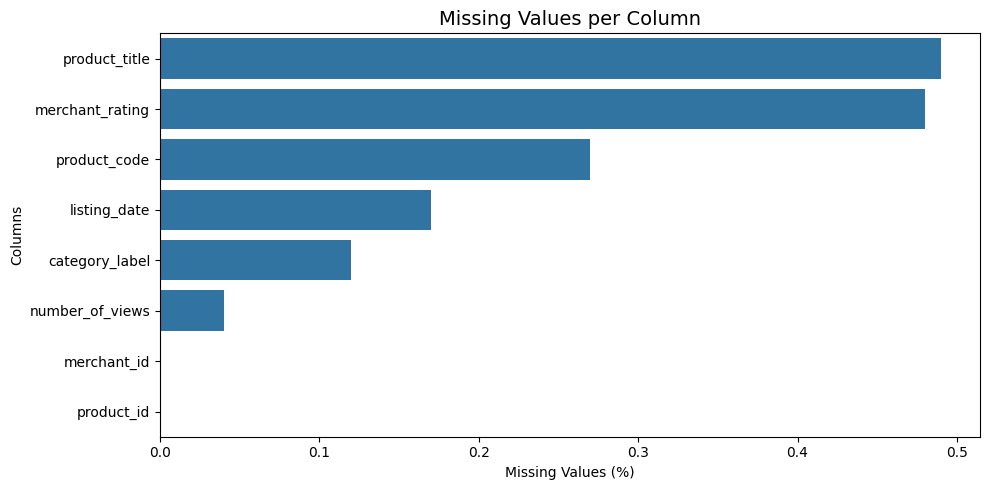

In [56]:
print(df.columns) # overview

# standardization columns
df.columns = ['product_id',
              'product_title',
              'merchant_id',
              'category_label',
              'product_code',
              'number_of_views',
              'merchant_rating',
              'listing_date'
              ]

# visualization using barplot
import seaborn as sns
import matplotlib.pyplot as plt

missing_values_percentage = (df.isna().sum()/ len(df) * 100).round(2)
missing_values_percentage = missing_values_percentage.sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_values_percentage.values,
    y=missing_values_percentage.index
)

plt.title("Missing Values per Column", fontsize=14)
plt.xlabel("Missing Values (%)")
plt.ylabel("Columns")

plt.tight_layout()
plt.show()

# ✅ Step 3:

a) Cleaning dataset

b) Data Type Inspection and Conversion

c) Checking  Column Contents

In [57]:
rows_before_cleaning = len(df) # len before cleaning

df = df.dropna() # delete rows with missing values

rows_after_cleaning = len(df) #  len after cleaning

print("---- Rows before cleaning:", rows_before_cleaning)
print("---- Rows after cleaning:", rows_after_cleaning)
print("-"*40)
print(df.dtypes)
print("-"*40)

print("--- Conversion 'listing_date' column to datetime.")
df["listing_date"] = pd.to_datetime(df["listing_date"], errors="coerce")
print("-"*40)

print("---- Checking conversion succeeded.")
print(df.dtypes)
print("-"*40)
print("---- Listing product_title column...")
print(df['product_title'].value_counts())
print("-"*40)
print("---- Listing category_label column...")
print(df['category_label'].value_counts())


---- Rows before cleaning: 35311
---- Rows after cleaning: 34760
----------------------------------------
product_id           int64
product_title       object
merchant_id          int64
category_label      object
product_code        object
number_of_views    float64
merchant_rating    float64
listing_date        object
dtype: object
----------------------------------------
--- Conversion 'listing_date' column to datetime.
----------------------------------------
---- Checking conversion succeeded.
product_id                  int64
product_title              object
merchant_id                 int64
category_label             object
product_code               object
number_of_views           float64
merchant_rating           float64
listing_date       datetime64[ns]
dtype: object
----------------------------------------
---- Listing product_title column...
product_title
washing machine                                                  89
built in fully integrated dishwasher              